In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

In [3]:
#load atlas
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_51120\4158968567.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


In [4]:
def plot_supression(fo_f):
    region_list = [['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']
    #region_list = ['i']
    dot_stims = np.unique([s.split("'")[1] for s in fo_f.columns if "[" in s])
    omr_stims = np.unique([s.split("'")[3] for s in fo_f.columns if "[" in s])
    fig, ax = plt.subplots(len(omr_stims), len(dot_stims), dpi=240, figsize=(15, 40))

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred =list(fo_f.index[(fo_f.filter(like=f"barred_").any(axis=1))])# & (fo_f['DSI2'] > -1)])

    for stimn, stim in enumerate(omr_stims):
        for dstimi, dstim in enumerate(dot_stims):
            overlap_stim = str([str(dstim), str(stim)])
            #barred = list(fo_f.index[(fo_f.filter(like=f"barred_{stim}").any(axis=1))& (np.abs(np.subtract(fo_f['dir'],utils.omr_angles[stim]))%360<=45)])
            fo_f_stim = fo_f[overlap_stim].loc[barred]
            #plot response
            ax_imshow = ax[stimn, dstimi]
            ax_imshow.imshow(template[140], cmap = 'gray_r', vmax = 6000)
            alphas = np.abs(fo_f_stim)
            alphas = np.nan_to_num((alphas - np.nanmin(alphas)) / (np.nanmax(alphas) - np.nanmin(alphas) + 1e-9), nan=0.0)
            ax_imshow.scatter(fo_f.loc[barred, 'xpos'], fo_f.loc[barred, 'ypos'], c = fo_f_stim, cmap = 'bwr', vmin = -0.1, vmax = 0.1, s =10, alpha =alphas, marker = '.')
            ax_imshow.set_axis_off()
            ax_imshow.set_title(overlap_stim)
    return fig

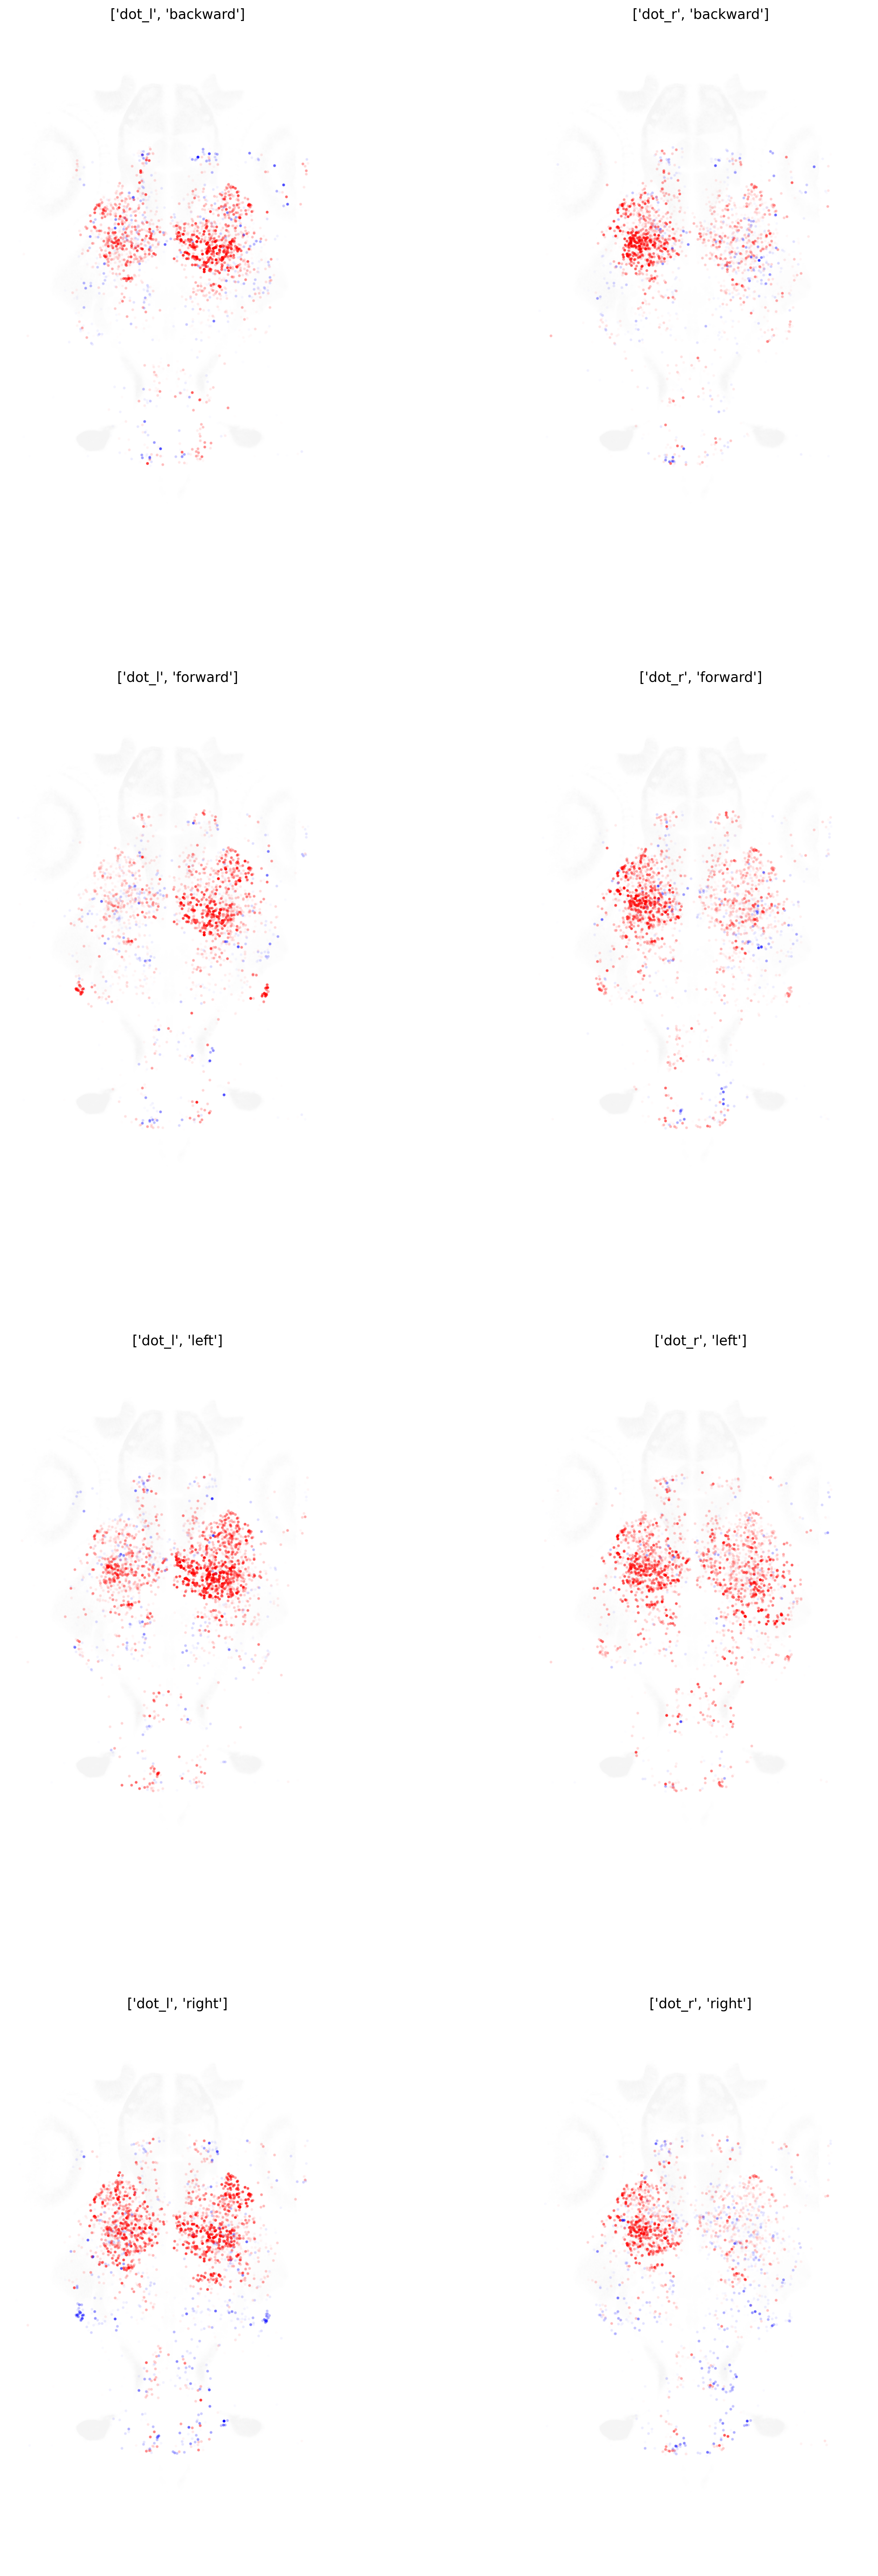

In [5]:

# paths = [r"C:\Data\Imaging\250912_overlap\fish3",
# r"C:\Data\Imaging\250912_overlap\fish2_2",
#          r"C:\Data\Imaging\250912_overlap\fish5_2",
#          r"C:\Data\Imaging\250912_overlap\fish9",
# r"C:\Data\Imaging\250912_overlap\fish8",
#          r"C:\Data\Imaging\250912_overlap\fish15",
# r"C:\Data\Imaging\250912_overlap\fish13",
# r"C:\Data\Imaging\250912_overlap\fish14"]
# paths =      [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish3_overlap"]
paths = [
r"C:\Data\Imaging\251224_overlap\fish3_HB",
# r"C:\Data\Imaging\251224_overlap\fish5",
# r"C:\Data\Imaging\251224_overlap\fish5_HB",
# r"C:\Data\Imaging\251224_overlap\fish1",
# r"C:\Data\Imaging\251224_overlap\fish1_HB",
# r"C:\Data\Imaging\251224_overlap\fish2",
# r"C:\Data\Imaging\251224_overlap\fish2_HB",
r"C:\Data\Imaging\251224_overlap\fish3"]

fo_f_df = []
for path in paths:
    fo_f = pd.read_csv(path + '//analyze_results//fo_f.csv', index_col = 0)
    grating_response = pd.read_csv(path + '//analyze_results//dot_responses.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    fo_f = pd.concat([fo_f,grating_response, new_poses], ignore_index = False, axis = 1)
    fo_f.loc[:, 'fish_id'] = path
    fo_f_df.append(fo_f)
fo_f_df = pd.concat(fo_f_df).reset_index()
fig = plot_supression(fo_f_df)
#plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//fo_o_dotcells_highDSI.png")
plt.show()
plt.close()

In [6]:
def plot_suppression_trace(fo_f_trace):
    region_list = [['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']
    #region_list = ['i']
    stims = fo_f_trace.stims.unique()
    stims = [s for s in stims if type(s) == str]
    dot_stims = np.unique([s.split("'")[1] for s in stims if "[" in s])
    omr_stims = np.unique([s.split("'")[3] for s in stims if "[" in s])
    fig, ax = plt.subplots(len(omr_stims), len(dot_stims), dpi=240, figsize=(5, 10))

    #only plot visually responsive neurons that have been somewhat barrcoded
    #barred = list(fo_f.index[(fo_f.filter(like=f"barred_").any(axis=1)) & (fo_f['DSI2'] > 0.5)])

    for stimn, stim in enumerate(omr_stims):
        for dstimi, dstim in enumerate(dot_stims):
            overlap_stim = str([str(dstim), str(stim)])
            trace_df = fo_f_trace[fo_f_trace.stims == overlap_stim]
            #plot response
            ax_trace = ax[stimn, dstimi]
            ax_trace.set_title(overlap_stim)
            for mod,c in zip(['pos', 'neg'], ['red', 'blue']):
                for real_stim, l in zip(['gratings', 'overlap'], ['-', ':']):
                    trace_smalldf = trace_df[(trace_df.modulations == mod) & (trace_df.real_stim == real_stim)].drop(['index', 'stims', 'modulations', 'real_stim', 'fish_id', 'xpos', 'ypos', 'zpos', 'zpos_atlas', 'regions'], axis = 1)
                    f_mean = trace_smalldf.mean(axis = 0)
                    f_sem = trace_smalldf.std(axis = 0)/ np.sqrt(len(trace_smalldf))
                    ax_trace.plot(f_mean, c = c, linestyle = l)
                    ax_trace.fill_between(range(len(f_mean)), f_mean - f_sem, f_mean + f_sem, color=c, alpha=0.1, linewidth = 0)
            ax_trace.set_xticks([])
            ax_trace.set_xticklabels([])
            stationary_frame = 41
            response_startframe = 49
            response_endframe = 57
            ax_trace.axvline(stationary_frame, color='grey', linestyle='--')
            ax_trace.axvline(response_startframe, color='grey', linestyle='--')
            ax_trace.axvline(response_endframe, color='grey', linestyle='--')
            ax_trace.set_ylim([.24, .34])
    return fig

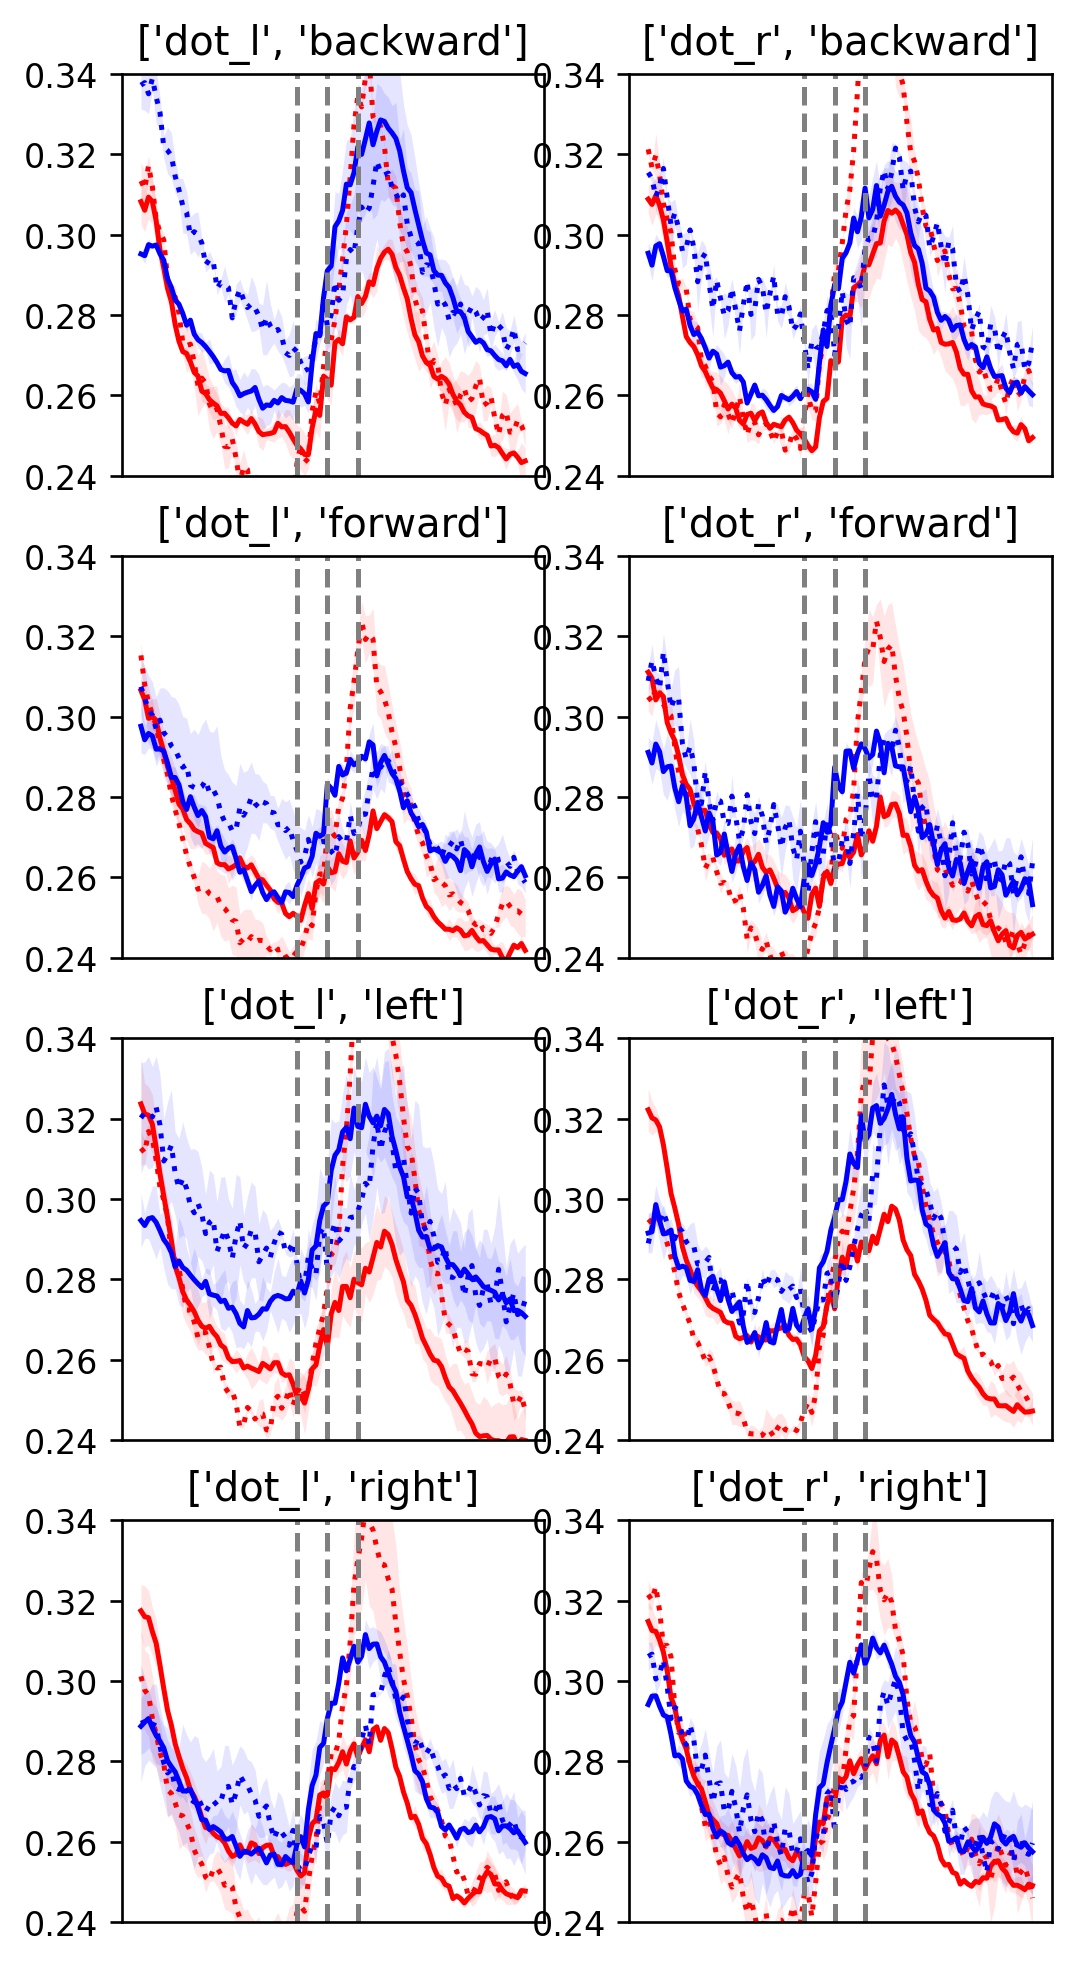

In [9]:
paths = [
r"C:\Data\Imaging\251224_overlap\fish3_HB",
# r"C:\Data\Imaging\251224_overlap\fish5",
# r"C:\Data\Imaging\251224_overlap\fish5_HB",
# r"C:\Data\Imaging\251224_overlap\fish1",
# r"C:\Data\Imaging\251224_overlap\fish1_HB",
# r"C:\Data\Imaging\251224_overlap\fish2",
# r"C:\Data\Imaging\251224_overlap\fish2_HB",
r"C:\Data\Imaging\251224_overlap\fish3"]

fo_f_trace_df = []
for path in paths:
    fo_f_trace = pd.read_csv(path + '//analyze_results//fo_f_trace.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    fo_f_trace = pd.concat([fo_f_trace,new_poses], ignore_index = False, axis = 1)
    fo_f_trace.loc[:, 'fish_id'] = path
    fo_f_trace_df.append(fo_f_trace)
fo_f_trace_df = pd.concat(fo_f_trace_df).reset_index()
fig = plot_suppression_trace(fo_f_trace_df)
#plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//fo_o_trace.svg")
plt.show()
plt.close()

In [130]:
def plot_supression_dsi(fo_f):
    #region_list = [['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']
    region_list = ['i']
    dot_stims = np.unique([s.split("'")[1] for s in fo_f.columns if "[" in s])
    omr_stims = np.unique([s.split("'")[3] for s in fo_f.columns if "[" in s])
    fig= plt.figure(dpi=240, figsize=(15, 30))
    gs = gridspec.GridSpec(len(omr_stims) * 2, len(dot_stims) * 2, figure=fig)
    #only plot visually responsive neurons that have been somewhat barrcoded
    #barred = list(fo_f.index[(fo_f.filter(like=f"barred_").any(axis=1)) & (fo_f['DSI2'] > 0.5)])
    for r, region in enumerate(region_list):
        if type(region) == list:
            region_n = set(fo_f.index[fo_f['regions'].apply(lambda x: any(ri in x for ri in region))])
        else:
            region_n = set(fo_f.index)#=set(fo_f.index[fo_f['regions'].apply(lambda x: region in x)])#
        for stimn, stim in enumerate(omr_stims):
            for dstimi, dstim in enumerate(dot_stims):
                overlap_stim = str([str(dstim), str(stim)])
                pos_n = set(fo_f.index[(fo_f[overlap_stim]>0)])
                neg_n = set(fo_f.index[(fo_f[overlap_stim]<0)])
                pos_n = list(pos_n & region_n)
                neg_n = list(neg_n & region_n)
                ax_heat_pos = fig.add_subplot(gs[stimn * 2 + r, dstimi * 2], polar = True)
                ax_heat_pos.set_theta_offset(np.pi/2)
                ax_heat_pos.set_theta_direction(-1)
                ax_heat_neg = fig.add_subplot(gs[stimn * 2 + r, dstimi * 2 + 1], polar = True)
                ax_heat_neg.set_theta_offset(np.pi/2)
                ax_heat_neg.set_theta_direction(-1)

                #plot heatmap
                theta_bins = np.linspace(-np.pi, np.pi, 73)
                r_bins = np.linspace(0, 1, 10)
                dirs_rad = np.deg2rad(fo_f.loc[pos_n, 'dir'].values)
                radii = fo_f.loc[pos_n, 'DSI2'].values
                H, theta_edges, r_edges = np.histogram2d(dirs_rad, radii, bins=[theta_bins, r_bins])
                H = H / H.sum() * 100
                T, R = np.meshgrid(theta_edges, r_edges)
                ax_heat_pos.pcolormesh(T, R, H.T, vmin = 0, vmax = 0.45)
                ax_heat_pos.set_axis_off()
                #plot heatmap
                dirs_rad = np.deg2rad(fo_f.loc[neg_n, 'dir'].values)
                radii = fo_f.loc[neg_n, 'DSI2'].values
                H, theta_edges, r_edges = np.histogram2d(dirs_rad, radii, bins=[theta_bins, r_bins])
                H = H / H.sum() * 100
                T, R = np.meshgrid(theta_edges, r_edges)
                ax_heat_neg.pcolormesh(T, R, H.T, vmin = 0, vmax = 0.6)
                ax_heat_neg.set_axis_off()

                if r == 0: ax_heat_pos.set_title(overlap_stim)
    return fig

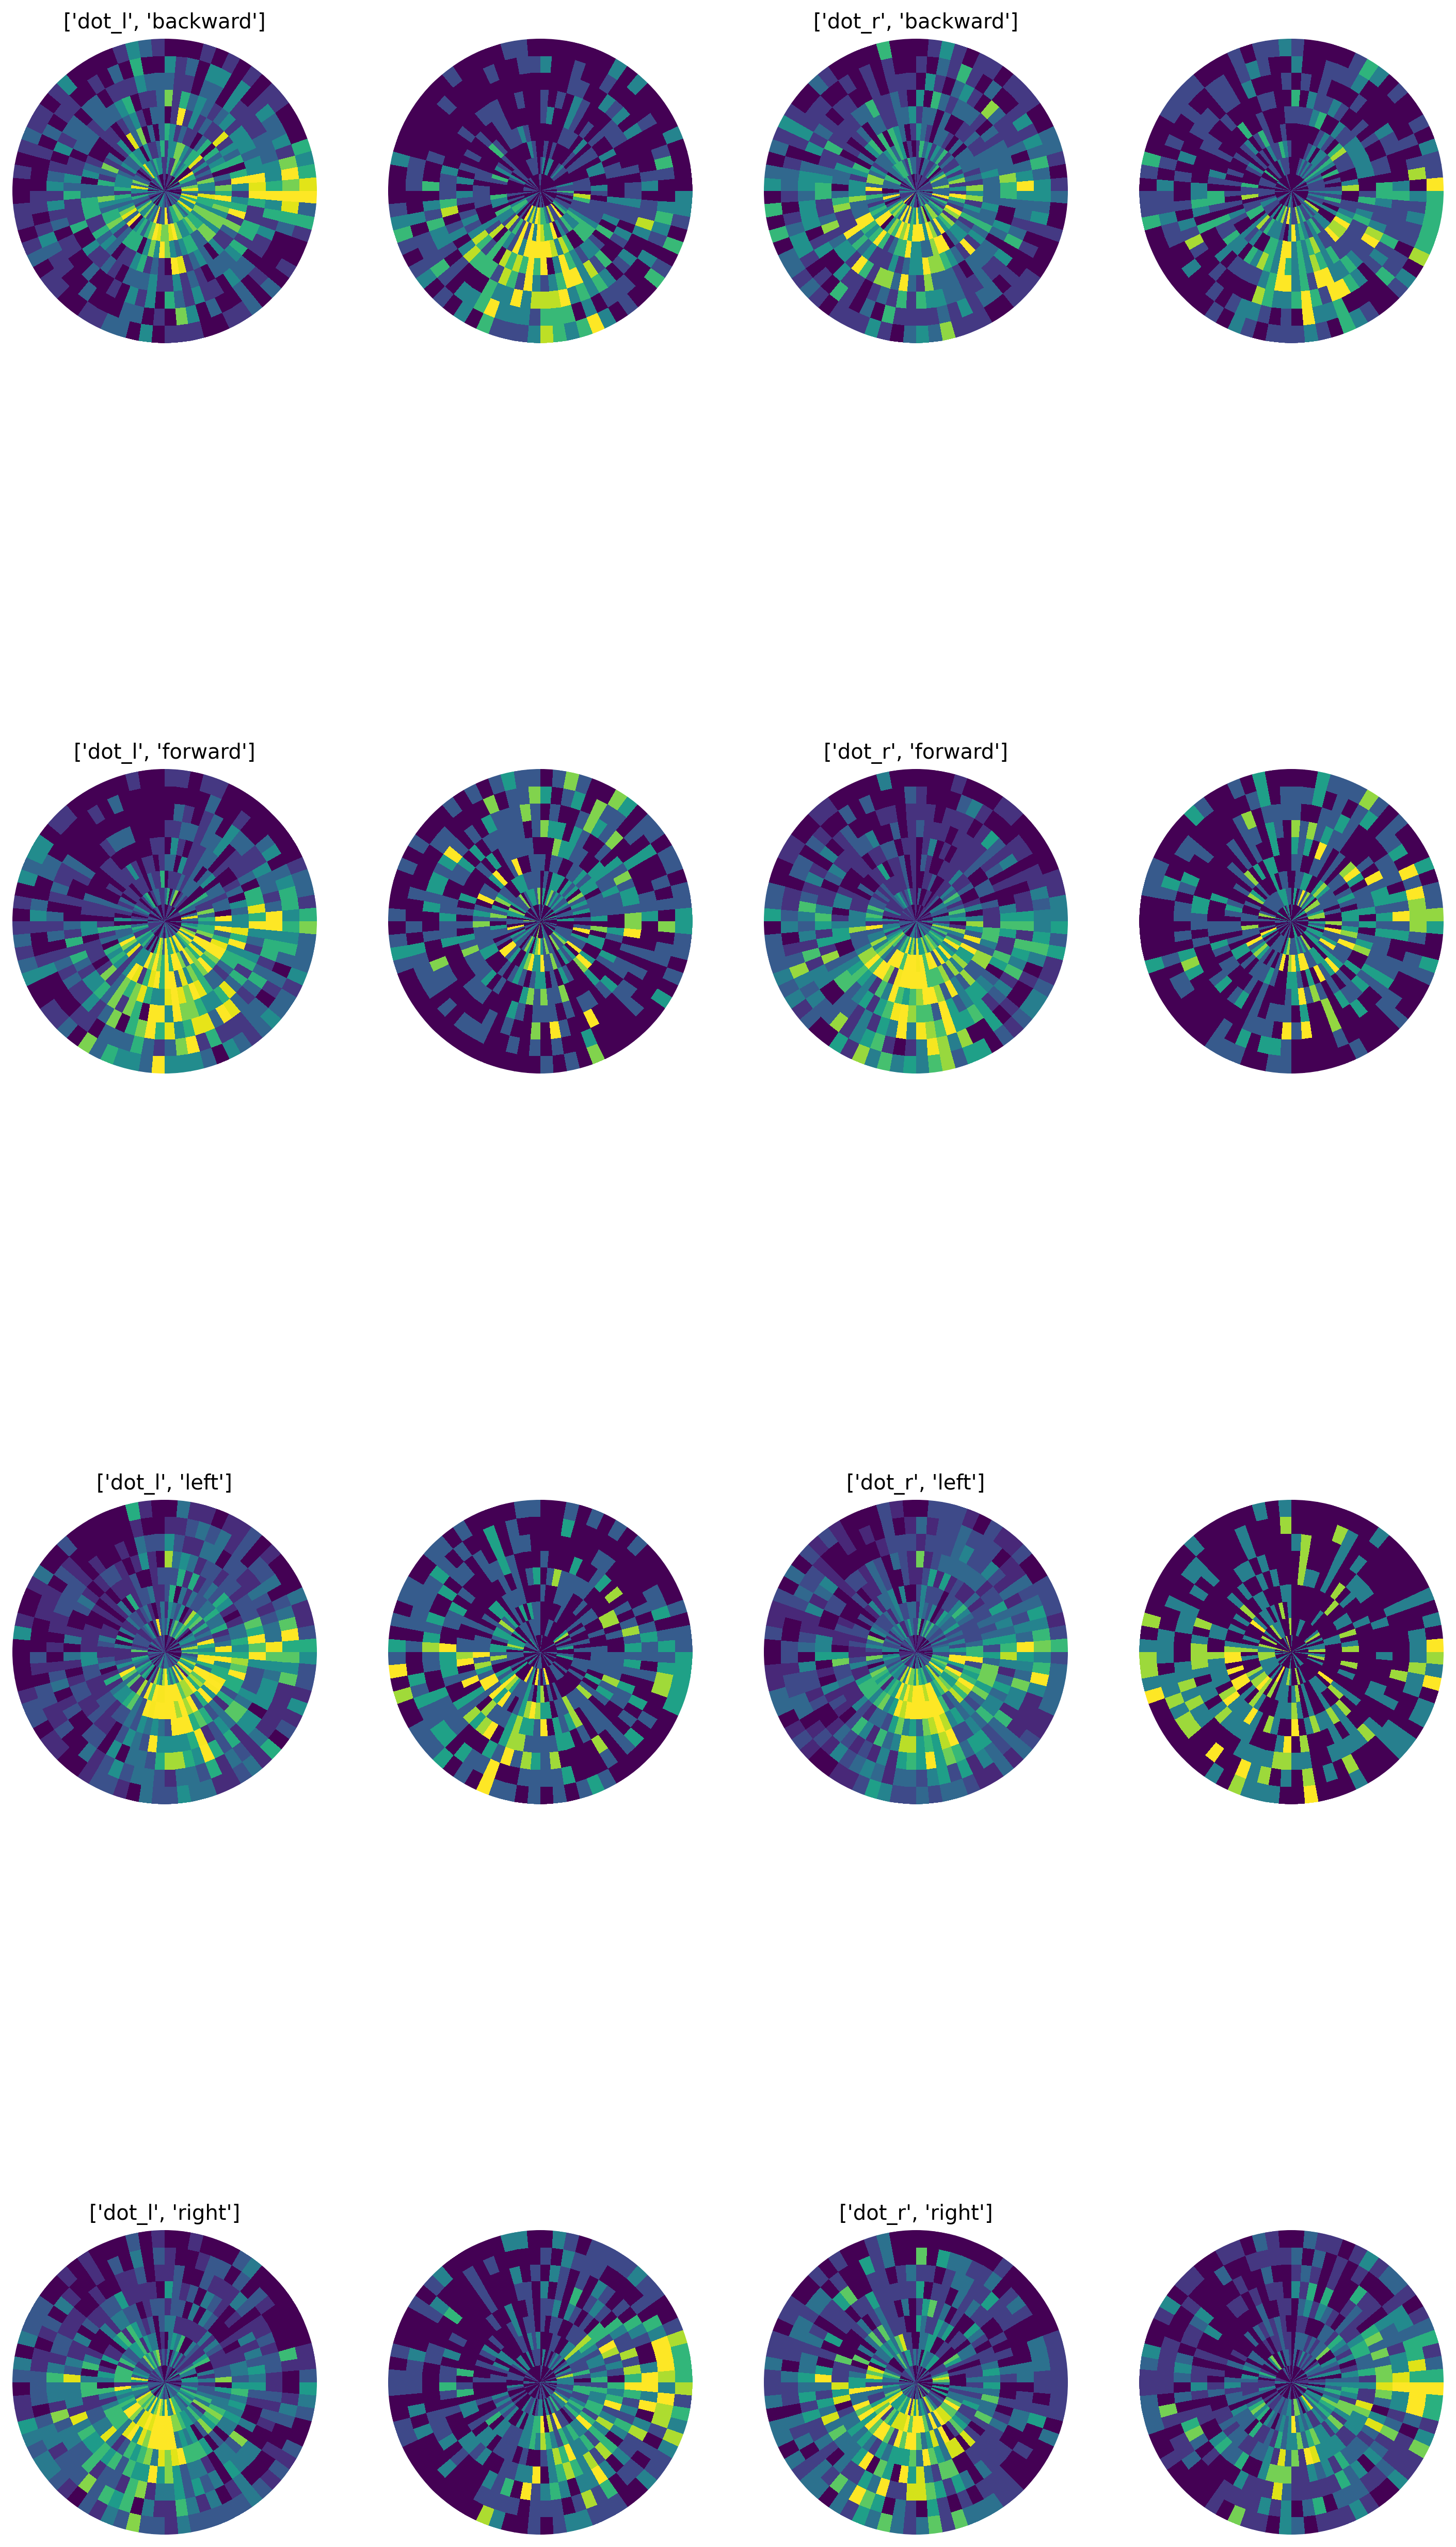

In [135]:
paths =      [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
 r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
 r"C:\Data\Imaging\251021_dotsweep\fish3_overlap"]
paths = [
r"C:\Data\Imaging\251224_overlap\fish3_HB",
r"C:\Data\Imaging\251224_overlap\fish5",
r"C:\Data\Imaging\251224_overlap\fish5_HB",
r"C:\Data\Imaging\251224_overlap\fish1",
r"C:\Data\Imaging\251224_overlap\fish1_HB",
r"C:\Data\Imaging\251224_overlap\fish2",
r"C:\Data\Imaging\251224_overlap\fish2_HB",
r"C:\Data\Imaging\251224_overlap\fish3"]
paths = [r"C:\Data\Imaging\250912_overlap\fish3",
r"C:\Data\Imaging\250912_overlap\fish2_2",
         r"C:\Data\Imaging\250912_overlap\fish5_2",
         r"C:\Data\Imaging\250912_overlap\fish9",
r"C:\Data\Imaging\250912_overlap\fish8",
         r"C:\Data\Imaging\250912_overlap\fish15",
r"C:\Data\Imaging\250912_overlap\fish13",
r"C:\Data\Imaging\250912_overlap\fish14"]
paths = [r"C:\Data\Imaging\251224_overlap\fish3_HB",
           r"C:\Data\Imaging\251224_overlap\fish3"]
fo_f_df = []
for path in paths:
    fo_f = pd.read_csv(path + '//analyze_results//fo_f.csv', index_col = 0)
    grating_response = pd.read_csv(path + '//analyze_results//grating_responses.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    fo_f = pd.concat([fo_f,grating_response, new_poses], ignore_index = False, axis = 1)
    fo_f.loc[:, 'fish_id'] = path
    fo_f_df.append(fo_f)
fo_f_df = pd.concat(fo_f_df).reset_index()
fig = plot_supression_dsi(fo_f_df)
#plt.savefig(r"C:\Data\Imaging\250912_overlap\All_imaging//fo_o_dsi.png")
plt.show()
plt.close()